# Compute Engine Tutorial

This tutorial will demonstrate the essential functionality of the Compute Engine.
It assumes a basic knowledge of xarray data structures and functions: https://docs.xarray.dev/en/stable/

## Installation

Open a terminal, create a new environment with `venv` or Conda, enter the top-level directory of the repository, and install the package:
```
pip install -e ./
```
Then, install Jupyter, open the lab, and open this tutorial with it:
```
pip install jupyterlab
jupyter lab
```

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Like any package, we will import the engine:

In [26]:
import climadace as ce

## Loading data

CE provides wrappers for some xarray functions opening data files.
They work like their xarray pendents, with the exception of ensuring a chunked loading of data (using `dask`), and a decoding of coordinates.

In [27]:
hazard = ce.open_dataarray("data/hazard/Europe_RP100_filled_depth.tif")
hazard

<xarray.DataArray 'band_data' (band: 1, y: 51992, x: 110162)> Size: 23GB
dask.array<open_dataset-band_data, shape=(1, 51992, 110162), dtype=float32, chunksize=(1, 5632, 5632), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 881kB -24.54 -24.54 -24.54 ... 67.26 67.26 67.26
  * y            (y) float64 416kB 71.13 71.13 71.13 71.13 ... 27.81 27.81 27.81
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area

CE also ensures that geographic information of the datasets is loaded appropriately.
Internally, it uses `rioxarray` and OpenDataCube.Geo (`odc.geo`), which operate on top of RasterIO.  Both packages provide xarray plugins to represent the additional geospatial information.
ODC uses the abstraction of a "GeoBox", a pixel array of geographical data including information on the resultion and the coordinate reference system (or projection).
The coordinates of the dataset are the centers of the pixels.
CE ensures that the plugins are enabled.

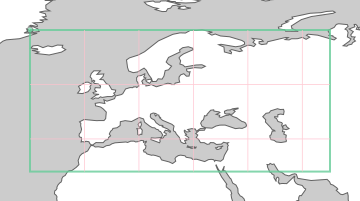

In [28]:
hazard.odc.geobox

In [29]:
exposure = ce.open_dataarray("data/exposure/deu_ppp_2000_1km_Aggregated_UNadj.tif")
exposure

<xarray.DataArray 'band_data' (band: 1, y: 934, x: 1100)> Size: 4MB
dask.array<open_dataset-band_data, shape=(1, 934, 1100), dtype=float32, chunksize=(1, 934, 1100), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  3301.6967773438
    STATISTICS_MEAN:     122.93104760496
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   266.87357580513

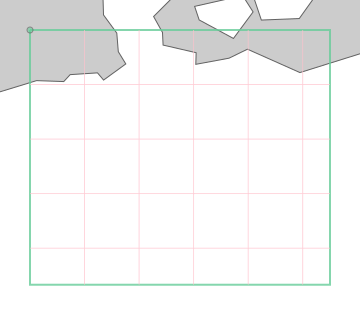

In [30]:
exposure.odc.geobox

Expanding the "WKT" information above, you will find that both datasets are in the same coordinate reference system (CRS).
Still, the exact coordinates do not match.
For any kind of xarray operation including two separate DataArrays or Datasets, the coordinates of dimensions with the same name have to be aligned.
The following operation performs the alignment and also makes sure that geographical coordinates and single-array datasets are named the same.

After the following operation, the GeoBoxes of both objects match:

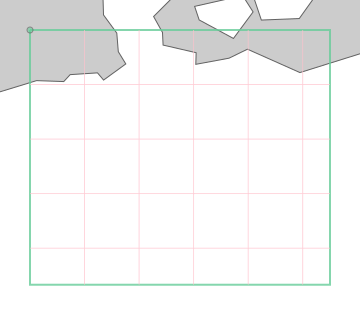

In [31]:
hazard, exposure = ce.align(hazard, exposure)
hazard.odc.geobox

## Impact Calculation

We now loaded the data (or prepared to load at least).
Next, we need to define the vulnerability to compute the impact.
The vulnerability is encoded as a function of the hazard intensity (or a similar quantity), that returns a "damage factor" with which the exposure will be multiplied to yield the impact.
Let's define a parameterized sigmoidal function in Python first:

In [32]:
import numpy as np


def sigmoid(x, threshold=0.1, half_point=1.0, exponent=3, scale=1.0):
    foo = (x - threshold) / (half_point - threshold)
    return np.maximum(scale * foo**exponent / (1 + foo**exponent), 0.0)

In [33]:
# REGISTRY = ce.ImpactFunctionRegistry()
# REGISTRY.allow_overwrite = True

CE supports any kind of function that takes an xarray Dataset as argument and returns another dataset.
Since xarray uses a dispatch of universal functions internally, we can formulate a simple function with numpy-like object handling in most cases.
So indeed, the above function would already qualify as an impact function in CE.
Nonetheless, CE provides additional facilities for handling impact functions.

The `impact_function` decorator can be used to explicitly mark a function as impact function.
It allows for registering a function using the `name` argument, and interpolating the function using `interp_at`.

In [34]:
# TODO: Write interpolated impact function
@ce.impact_function(interp_at=np.linspace(0, 5, 50), name="RF1")
def my_func(x):
    return sigmoid(x, threshold=0.5)

/var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/ipykernel_7536/1723656814.py:6: RuntimeWarning: divide by zero encountered in divide
  return np.maximum(scale * foo**exponent / (1 + foo**exponent), 0.0)


The main structure for the impact and aggregate computation is the `Engine`.
It requires the datasets for `hazard` and `exposure`, and the impact function as input.

In [ ]:
engine = ce.Engine(
    hazard=hazard,
    exposure=exposure,
    impf_map=my_func,
)
impact = engine.impact()
impact

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1, x: 1100, y: 934)
    Coordinates:
      * band         (band) int64 8B 1
      * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
      * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
        spatial_ref  int64 8B 0
    Data variables:
        band_data    (band, y, x) float64 8MB dask.array<chunksize=(1, 934, 1100), meta=np.ndarray>

Note that by default, CE loads data lazily with dask.
All computations performed with that data are therefore also lazy.
As you can see, the resulting array is still a dask array.
No computations have been performed, yet.
They will be carried out when the data is requested for storing or plotting, or when `.compute()` is called on the xarray data structure.

In the next step, we will plot the impact result.
Only when this cell is executed, the impact is actually computed.
By virtue of dask, it is then also discarded again.
Therefore, exercise caution to avoid computing the same data multiple times!

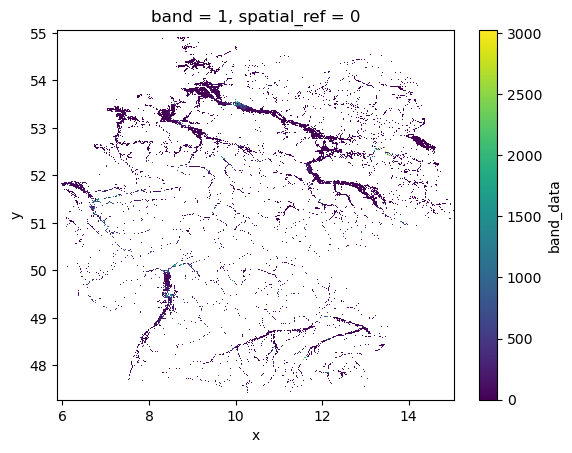

In [36]:
impact["band_data"].plot()

More than in the pixel-wise data, we are usually interested in spatial or temporal aggregates and averages of the impact.
We can compute them with `Engine.aggregate`.
For example, the `at_event` aggregate sums all values along the spatial axes of the data and thus returns the total impact of each event.

Since we have not explicitly requested the computed impact data, the impact is now computed again and then the aggregation is performed.

In [38]:
at_event = engine.aggregate(ce.at_event)
at_event

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1)
    Coordinates:
      * band         (band) int64 8B 1
        spatial_ref  int64 8B 0
    Data variables:
        band_data    (band) float64 8B 5.229e+06

## Multi-dim datasets

In [96]:
import xarray as xr

RP = [10, 50, 100]
hazard = xr.concat(
    [ce.open_dataarray(f"data/hazard/Europe_RP{rp}_filled_depth.tif") for rp in RP],
    dim=xr.DataArray(RP, dims=("return_period")),
)
hazard

<xarray.DataArray 'band_data' (return_period: 3, band: 1, y: 51992, x: 110162)> Size: 69GB
dask.array<concatenate, shape=(3, 1, 51992, 110162), dtype=float32, chunksize=(1, 1, 5632, 5632), chunktype=numpy.ndarray>
Coordinates:
  * band           (band) int64 8B 1
  * x              (x) float64 881kB -24.54 -24.54 -24.54 ... 67.26 67.26 67.26
  * y              (y) float64 416kB 71.13 71.13 71.13 ... 27.81 27.81 27.81
    spatial_ref    int64 8B 0
  * return_period  (return_period) int64 24B 10 50 100
Attributes:
    AREA_OR_POINT:  Area

In [97]:
YEAR = [2000, 2001]
exposure = xr.concat(
    [
        ce.open_dataarray(f"data/exposure/deu_ppp_{year}_1km_Aggregated_UNadj.tif")
        for year in YEAR
    ],
    dim=xr.DataArray(YEAR, dims=("year")),
)
exposure

<xarray.DataArray 'band_data' (year: 2, band: 1, y: 934, x: 1100)> Size: 8MB
dask.array<concatenate, shape=(2, 1, 934, 1100), dtype=float32, chunksize=(1, 1, 934, 1100), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B 0
  * year         (year) int64 16B 2000 2001
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  3301.6967773438
    STATISTICS_MEAN:     122.93104760496
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   266.87357580513

In [98]:
hazard, exposure = ce.align(hazard, exposure)

In [99]:
hazard = hazard.sp.to_sparse().compute()
hazard

Format,nanarray
Data Type,float32
Shape,"(3, 1, 934, 1100)"
nnz,197630
Density,0.06411978456946336
Read-only,True
Size,2.3M
Storage ratio,0.19


In [100]:
engine = ce.Engine(
    hazard=hazard,
    exposure=exposure,
    impf_map={ce.FuncType.leaf: "RF1"},
)
impact = engine.impact()
impact

<xarray.DataTree>
Group: /
    Dimensions:        (band: 1, x: 1100, y: 934, return_period: 3, year: 2)
    Coordinates:
      * band           (band) int64 8B 1
      * x              (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
      * y              (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
      * return_period  (return_period) int64 24B 10 50 100
        spatial_ref    int64 8B 0
      * year           (year) int64 16B 2000 2001
    Data variables:
        band_data      (return_period, band, y, x, year) float64 49MB dask.array<chunksize=(3, 1, 934, 1100, 1), meta=sparse.numba_backend._coo.core.COO>

In [104]:
impact = impact.compute()

In [105]:
diff = impact.sel(return_period=100, year=2000) - impact.sel(
    return_period=10, year=2000
)
diff

Format,gcxs
Data Type,float64
Shape,"(1, 934, 1100)"
nnz,42225
Density,0.04109889040295892
Read-only,True
Size,659.8K
Storage ratio,0.08
Compressed Axes,"(0,)"


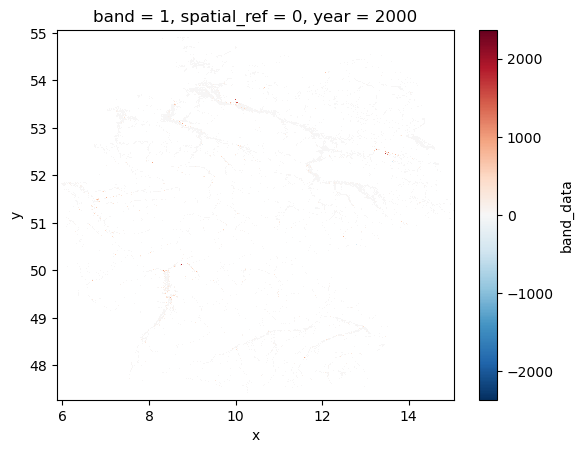

In [106]:
diff["band_data"].plot()

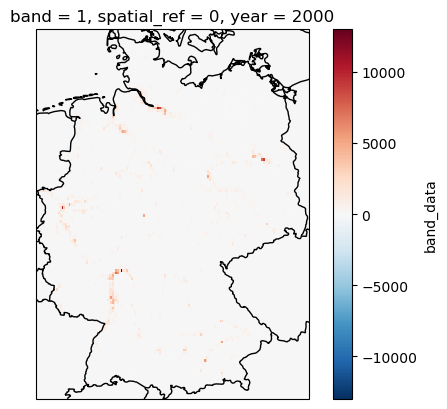

In [107]:
# TODO: Coarsen by 7
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Mercator()})

diff["band_data"].coarsen({"x": 7, "y": 7}, "pad").sum().plot(
    ax=ax, transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.BORDERS)
ax.coastlines("10m")

In [110]:
# TODO: Average annual impact
average_impact = engine.aggregate(
    lambda x: ce.average_event_impact(x, "return_period", 1.0 / impact["return_period"])
).compute()
average_impact.sp.to_dense().compute()

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1, year: 2)
    Coordinates:
      * band         (band) int64 8B 1
        spatial_ref  int64 8B 0
      * year         (year) int64 16B 2000 2001
    Data variables:
        band_data    (band, year) float64 16B 4.014e+06 3.94e+06

## GHSL

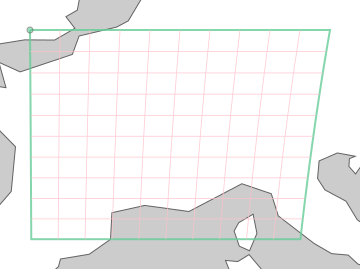

In [111]:
GHSL_YEAR = [2000, 2010, 2025]

hazard = xr.concat(
    [ce.open_dataarray(f"data/hazard/Europe_RP{rp}_filled_depth.tif") for rp in RP],
    dim=xr.DataArray(RP, dims=("return_period")),
)
exposure = ce.open_dataarray(
    "data/exposure/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif"
)
exposure.odc.geobox

In [112]:
hazard, exposure = ce.align(hazard, exposure)

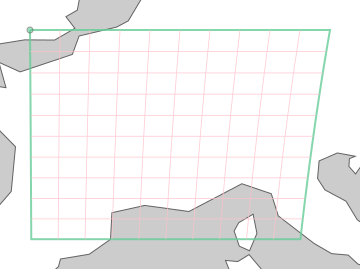

In [113]:
hazard.odc.geobox

In [114]:
hazard = hazard.sp.to_sparse().compute()

In [120]:
hazard

Format,gcxs
Data Type,float32
Shape,"(3, 1, 10000, 10000)"
nnz,13831623
Density,0.04610541
Read-only,True
Size,158.3M
Storage ratio,0.14
Compressed Axes,"(0,)"


In [115]:
import cartopy
import geopandas as gpd

ne = cartopy.io.shapereader.natural_earth(
    resolution="10m", category="cultural", name="admin_1_states_provinces"
)
ne_gdf = gpd.read_file(ne)
ne_gdf[ne_gdf["adm0_a3"] == "CHE"].head()

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
389,Admin-1 scale rank,9,CHE-165,165,CH-VS,None,CH,1,Valais,Vallais|Vallese|Wallis,...,None,None,None,None,None,None,None,None,None,"POLYGON ((7.84962 45.93971, 7.84839 45.93808, ..."
391,Admin-1 scale rank,9,CHE-168,168,CH-TI,None,CH,1,Ticino,Tesino|Tessin,...,None,None,None,None,None,None,None,None,None,"POLYGON ((8.72897 46.10824, 8.72389 46.10954, ..."
394,Admin-1 scale rank,9,CHE-170,170,CH-GR,None,CH,1,Graubünden,Graubünden|Grigioni|Grischun|Grisons,...,None,None,None,None,None,None,None,None,None,"POLYGON ((9.22483 46.23119, 9.21575 46.22106, ..."
765,Admin-1 scale rank,9,CHE-171,171,CH-SH,None,CH,1,Schaffhausen,Schaffhouse|Schaffusa|Sciaffusa,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((8.55822 47.80117, 8.58312 47.8..."
766,Admin-1 scale rank,9,CHE-174,174,CH-TG,None,CH,1,Thurgau,Thurgovie|Turgovia|Turg¢via,...,None,None,None,None,None,None,None,None,None,"POLYGON ((8.85194 47.67128, 8.85267 47.67079, ..."


In [116]:
exp_split = ce.split_from_geo(
    exposure,
    ne_gdf[ne_gdf["adm0_a3"].isin(["CHE", "DEU", "FRA"])],
    groupby_kws={"by": "adm0_a3"},
    mask_kws={"dropna": True},
)
exp_split

<xarray.DataTree>
Group: /
├── Group: /CHE
│       Dimensions:      (band: 1, y: 2122, x: 3558)
│       Coordinates:
│         * band         (band) int64 8B 1
│         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│           spatial_ref  int64 8B ...
│       Data variables:
│           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│       Attributes:
│           AREA_OR_POINT:  Area
├── Group: /DEU
│       Dimensions:      (band: 1, y: 4152, x: 5200)
│       Coordinates:
│         * band         (band) int64 8B 1
│         * x            (x) float64 42kB 4.39e+05 4.392e+05 ... 9.588e+05 9.59e+05
│         * y            (y) float64 33kB 6e+06 6e+06 6e+06 ... 5.585e+06 5.585e+06
│           spatial_ref  int64 8B ...
│       Data variables:
│           band_data    (band, y, x) float64 173MB dask.array<chunksize=(1, 3333, 3333), meta=np.ndarray>
│       Attributes:
│           AREA_OR_POINT:  Area
└── Group: /FRA
        Dimensions:      (band: 1, y: 9869, x: 7588)
        Coordinates:
          * band         (band) int64 8B 1
          * x            (x) float64 61kB -4.095e+04 -4.085e+04 ... 7.952e+05 7.954e+05
          * y            (y) float64 79kB 5.987e+06 5.987e+06 5.987e+06 ... 5e+06 5e+06
            spatial_ref  int64 8B ...
        Data variables:
            band_data    (band, y, x) float64 599MB dask.array<chunksize=(1, 3333, 3333), meta=np.ndarray>
        Attributes:
            AREA_OR_POINT:  Area

In [117]:
ce.split_from_geo(
    exp_split["/CHE"],
    ne_gdf[ne_gdf["adm0_a3"] == "CHE"],
    groupby_kws={"by": "iso_3166_2"},
    # mask_kws={"dropna": True},
    inplace=True,
)
exp_split

<xarray.DataTree>
Group: /
├── Group: /CHE
│   ├── Group: /CHE/CH-AG
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ├── Group: /CHE/CH-AI
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ├── Group: /CHE/CH-AR
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ...
│   ├── Group: /CHE/CH-VS
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ├── Group: /CHE/CH-ZG
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   └── Group: /CHE/CH-ZH
│           Dimensions:      (band: 1, y: 2122, x: 3558)
│           Coordinates:
│             * band         (band) int64 8B 1
│             * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│             * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│               spatial_ref  int64 8B ...
│           Data variables:
│               band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│           Attributes:
│               AREA_OR_POINT:  Area
├── Group: /DEU
│       Dimensions:      (band: 1, y: 4152, x: 5200)
│       Coordinates:
│         * band         (band) int64 8B 1
│         * x            (x) float64 42kB 4.39e+05 4.392e+05 ... 9.588e+05 9.59e+05
│         * y            (y) float64 33kB 6e+06 6e+06 6e+06 ... 5.585e+06 5.585e+06
│           spatial_ref  int64 8B ...
│       Data variables:
│           band_data    (band, y, x) float64 173MB dask.array<chunksize=(1, 3333, 3333), meta=np.ndarray>
│       Attributes:
│  

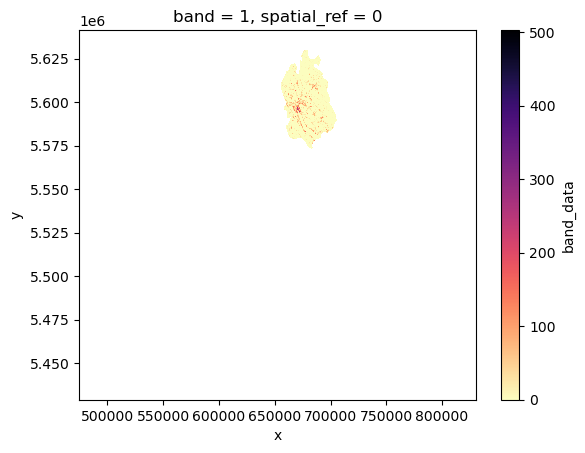

In [118]:
# TODO: Select ZH
exp_split["CHE/CH-ZH"]["band_data"].plot(cmap="magma_r")

In [127]:
engine = ce.Engine(
    hazard=hazard,
    exposure=exp_split,
    impf_map={
        "CHE": lambda inundation: xr.where(inundation > 0.5, 1.0, np.nan),
        "CH-ZH": "RF1",
        ce.FuncType.leaf: sigmoid,
    },
)
impact = engine.impact(compute=False)
impact

<xarray.DataTree>
Group: /
├── Group: /DEU
│       Dimensions:        (band: 1, return_period: 3, y: 4152, x: 5200)
│       Coordinates:
│         * band           (band) int64 8B 1
│         * return_period  (return_period) int64 24B 10 50 100
│         * y              (y) float64 33kB 6e+06 6e+06 6e+06 ... 5.585e+06 5.585e+06
│         * x              (x) float64 42kB 4.39e+05 4.392e+05 ... 9.588e+05 9.59e+05
│           spatial_ref    int32 4B 0
│       Data variables:
│           band_data      (return_period, band, y, x) float64 518MB dask.array<chunksize=(3, 1, 3333, 3333), meta=sparse.numba_backend._coo.core.COO>
├── Group: /FRA
│       Dimensions:        (band: 1, return_period: 3, y: 9869, x: 7588)
│       Coordinates:
│         * band           (band) int64 8B 1
│         * return_period  (return_period) int64 24B 10 50 100
│         * y              (y) float64 79kB 5.987e+06 5.987e+06 ... 5e+06 5e+06
│         * x              (x) float64 61kB -4.095e+04 -4.085e+04 ... 7.954e+05
│           spatial_ref    int32 4B 0
│       Data variables:
│           band_data      (return_period, band, y, x) float64 2GB dask.array<chunksize=(3, 1, 3333, 3333), meta=sparse.numba_backend._coo.core.COO>
└── Group: /CHE
    ├── Group: /CHE/CH-AG
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(3, 1, 2122, 3333), meta=sparse.numba_backend._coo.core.COO>
    ├── Group: /CHE/CH-AI
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(3, 1, 2122, 3333), meta=sparse.numba_backend._coo.core.COO>
    ├── Group: /CHE/CH-AR
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(3, 1, 2122, 3333), meta=sparse.numba_backend._coo.core.COO>
    ...
    ├── Group: /CHE/CH-VS
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(3, 1, 2122, 3333), meta=sparse.numba_backend._coo.core.COO>
    ├── Group: /CHE/CH-ZG
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * b

In [128]:
impact = impact.compute()

In [129]:
impact

Format,gcxs
Data Type,float64
Shape,"(3, 1, 4152, 5200)"
nnz,2180858
Density,0.03367018057408231
Read-only,True
Size,33.3M
Storage ratio,0.07
Compressed Axes,"(0,)"
Format,gcxs
Data Type,float64


In [131]:
4152 * 5200

21590400

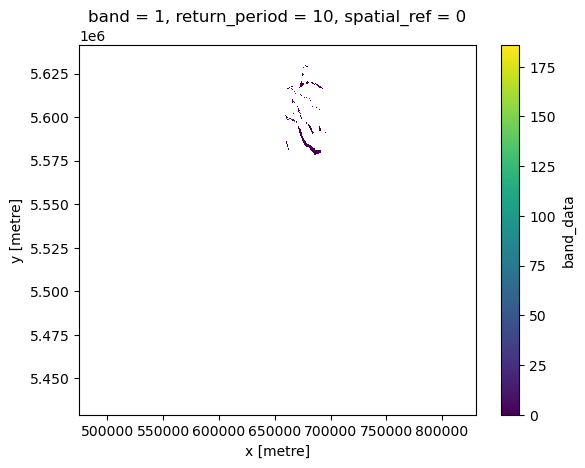

In [122]:
impact["CHE/CH-ZH"]["band_data"].sel(return_period=10).plot()

In [123]:
che_impact = (
    ce.merge_tree_dset(impact["CHE"])["band_data"].sel(return_period=100).compute()
)

In [132]:
che_impact

Format,coo
Data Type,float64
Shape,"(1, 2122, 3558)"
nnz,198594
Density,0.026303576281881135
Read-only,True
Size,6.1M
Storage ratio,0.11


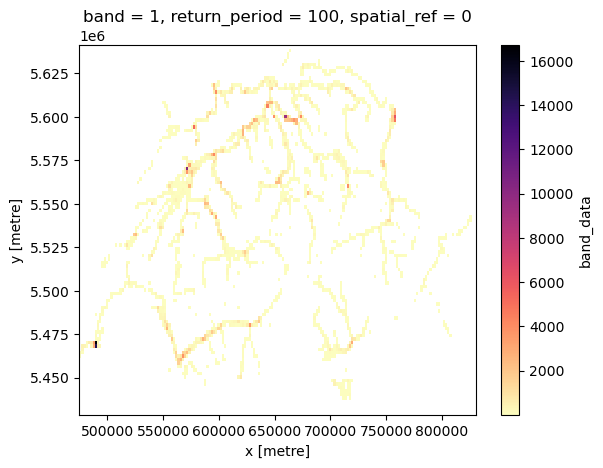

In [124]:
che_coarse = che_impact.coarsen(x=20, y=20, boundary="pad").sum()
che_coarse = che_coarse.where(che_coarse > 0)
che_coarse.plot(cmap="magma_r")

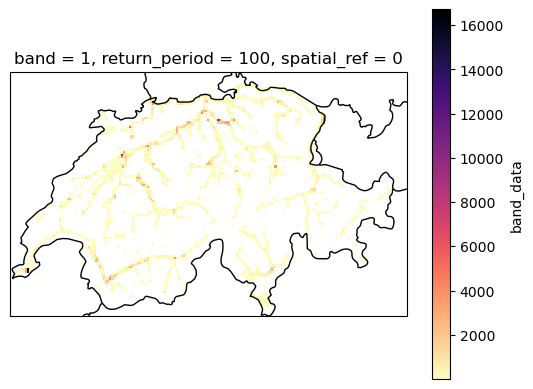

In [125]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Mercator()})
che_coarse.plot(ax=ax, transform=ccrs.Projection(che_coarse.rio.crs), cmap="magma_r")
ax.add_feature(cfeature.BORDERS)

In [ ]:
# with ce.dask_client(1, 2, "4GB"):
#     ce.merge_tree_dset(impact["CHE"].sel(return_period=10))["band_data"].plot()

In [30]:
output = engine.aggregate(
    {
        "CHE": ce.at_event,
        "DEU": lambda x: ce.average_event_impact(
            x, event_dim="return_period", weights=1.0 / impact["/DEU"]["return_period"]
        ),
    }
).compute()
output

<xarray.DataTree>
Group: /
├── Group: /DEU
│       Dimensions:      (band: 1)
│       Coordinates:
│         * band         (band) int64 8B 1
│           spatial_ref  int32 4B 0
│       Data variables:
│           band_data    (band) float64 8B 9.718e+05
├── Group: /FRA
└── Group: /CHE
    │   Dimensions:        (return_period: 3, band: 1)
    │   Coordinates:
    │     * band           (band) int64 8B 1
    │     * return_period  (return_period) int64 24B 10 50 100
    │       spatial_ref    int32 4B 0
    │   Data variables:
    │       band_data      (return_period, band) float64 24B 3.777e+05 ... 5.017e+05
    ├── Group: /CHE/CH-AG
    ├── Group: /CHE/CH-AI
    ├── Group: /CHE/CH-AR
    ...
    ├── Group: /CHE/CH-VS
    ├── Group: /CHE/CH-ZG
    └── Group: /CHE/CH-ZH

## CLIMADA Equivalent

In [32]:
from climada.hazard import Hazard

ne_gdf = gpd.read_file(ne)
hazard = Hazard.from_raster(
    "data/hazard/Europe_RP100_filled_depth.tif",
    dst_crs="ESRI:54009",
    geometry=ne_gdf[ne_gdf["adm0_a3"].isin(["DEU", "CHE", "FRA"])].geometry,
)

: 

In [ ]:
from climada.entity import Exposures

exp = Exposures.from_raster(
    "data/exposure/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif"
)